# Proposed neural-network pipeline: development evaluation on 2019

This notebook demonstrates the proposed **neural candidate stage** from fitting to predictions. It is self-contained: it does not import or change the existing model or automated-selection code. It reads the prepared historical CSV, not the download/SQL pipeline, and never reads the 2024 test file.

**Recipe:** 32/16 ReLU hidden layers; cross-entropy; SGD; ten fixed seeds; learning rates **0.1, 0.2, 0.3, 0.5**; patience **20**, restoring each network's lowest validation-loss checkpoint.

| Stage | Data | What it decides |
|---|---|---|
| Fit preprocessing and update network weights | All available elections through **2015** | Numeric medians/scales, categorical encoding, neural weights |
| Early stopping | Whole **2017** election | A best checkpoint for each seed and learning rate |
| Learning-rate selection | Whole **2017** election | Lowest **ensemble** validation log loss across the four candidates |
| Frozen-model evaluation | Whole **2019** election | Accuracy, changed-seat accuracy, probability quality and party errors |

The ten retained networks all use the same training/validation election split. Predictions average their probabilities; weights are not averaged. 2017 is used for both checkpoint and learning-rate selection but never for gradient updates. 2019 labels are used only after the fitted candidate has been selected.

**Interpretation:** 2019 has already been inspected in development, so this is a reproducible development evaluation, not a fresh independent test. This notebook evaluates the proposed neural candidate and a previous-winner baseline; it does not rerun the other model families or claim the neural network wins automated model selection.

## Executed result

The 2017 validation search selected **learning rate 0.3**. On all **632** labelled 2019 constituencies, the selected ten-seed ensemble achieved **90.19% accuracy** and **35.53% changed-seat accuracy**, with log loss **0.2437**. The previous-winner baseline achieved **87.97%** overall accuracy.

These results reproduce the preceding study. They do not erase its weaker 2005 and 2015 results or establish that this candidate wins against the other pipeline models.

In [1]:
from pathlib import Path
from typing import Any, TypedDict
import copy, hashlib, json, platform, time
import numpy as np
from numpy.typing import NDArray
import pandas as pd
from scipy import sparse
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.metrics import confusion_matrix, classification_report

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "TEST_TRAIN/train.csv").exists())
DATA_PATH = ROOT / "TEST_TRAIN/train.csv"
OUTPUT_DIR = ROOT / "Analysis and model development/nn_proposed_pipeline_2019_results"
SEEDS = tuple(range(101223, 101233))
LEARNING_RATES = (0.1, 0.2, 0.3, 0.5)
HIDDEN_SIZES = (32, 16)
BATCH_SIZE = 64
MAX_EPOCHS = 1000  # Safety cap, not a target duration.
PATIENCE = 20
MIN_DELTA = 0.0
EVALUATION_YEAR = 2019
torch.set_num_threads(1)
FEATURE_COLUMNS = [
    "country/region",
    "previous_majority_proportion",
    "previous_winner",
    "Conservative",
    "Labour",
    "LD",
    "incumbent",
    "previous_con_share",
    "previous_lib_share",
    "previous_lab_share",
    "previous_natSW_share",
    "projected_con_share",
    "projected_lib_share",
    "projected_lab_share",
]
CATEGORICAL_COLUMNS = ["country/region", "previous_winner", "incumbent"]
NUMERIC_COLUMNS = [
    column for column in FEATURE_COLUMNS if column not in CATEGORICAL_COLUMNS
]




## 1. Separate the evaluation election before fitting

The wrapper receives only elections before 2019. It holds out the latest supplied election (2017) in full and updates weights on all earlier elections (through 2015). Missing predictors are allowed and handled using the training rows; missing outcome labels raise an error. No labelled 2019 rows are excluded from the primary evaluation.

In [2]:
data = pd.read_csv(DATA_PATH)
data["election"] = pd.to_numeric(data["election"], errors="raise")
assert data.election.notna().all() and data.winner.notna().all()
historical_data = data.loc[data.election < EVALUATION_YEAR].copy()
evaluation_data = data.loc[data.election == EVALUATION_YEAR].copy()
assert historical_data.election.max() == 2017 and not evaluation_data.empty
assert historical_data.loc[historical_data.election < 2017].election.max() == 2015
split_summary = pd.DataFrame([
    {"role": "Weight updates and preprocessing", "elections": sorted(historical_data.loc[historical_data.election < 2017, "election"].unique().tolist()), "rows": int((historical_data.election < 2017).sum())},
    {"role": "Checkpoint and learning-rate selection", "elections": [2017], "rows": int((historical_data.election == 2017).sum())},
    {"role": "Development evaluation", "elections": [2019], "rows": len(evaluation_data)},
])
display(split_summary)


,role,elections,rows
0,Weight updates and preprocessing,"[1987, 1992, 1997, 2001, 2005, 2010, 2015]",4441
1,Checkpoint and learning-rate selection,[2017],632
2,Development evaluation,[2019],632


## 2. Preprocessing and individual network training

Numeric predictors are median-imputed and standardised. Categorical predictors are imputed to a missing-category label and one-hot encoded, ignoring unseen categories at prediction time. Each seed's preprocessing is fitted only on weight-update rows. The five-class output supplies raw logits to cross-entropy; softmax is used for predictions.

SGD has no momentum or weight decay. After each epoch, validation cross-entropy is measured on all of 2017. Any strictly lower loss saves a checkpoint and resets patience. Twenty epochs without improvement stops the run, and the saved checkpoint is restored. The first epoch always supplies a finite checkpoint or fitting fails explicitly.

In [ ]:
def make_preprocessor() -> ColumnTransformer:
    """Create preprocessing to fit on training rows and reuse for prediction."""
    return ColumnTransformer([
        # Fill missing numbers with training medians, then centre and scale them.
        # Keep even entirely missing columns so the feature layout stays stable.
        ("numeric", Pipeline([
            ("impute", SimpleImputer(strategy="median", keep_empty_features=True)),
            ("scale", StandardScaler()),
        ]), NUMERIC_COLUMNS),
        ("categorical", Pipeline([
            # Treat missing categories as a named category. One-hot encoding makes
            # a separate indicator column for each category seen during fitting;
            # unseen categories at prediction time get all-zero indicators.
            ("impute", SimpleImputer(
                strategy="constant", fill_value="__MISSING__", keep_empty_features=True
            )),
            ("encode", OneHotEncoder(handle_unknown="ignore")),
        ]), CATEGORICAL_COLUMNS),
    ])


def as_features(matrix: NDArray[Any] | sparse.spmatrix) -> torch.Tensor:
    """Convert sklearn's feature matrix into a dense float32 PyTorch tensor."""
    # One-hot encoding can produce sparse matrices; these linear layers need dense input.
    if sparse.issparse(matrix):
        matrix = matrix.toarray()
    array = np.asarray(matrix, dtype=np.float32)
    # Fail early if preprocessing leaves NaN or infinite values in the predictors.
    if not np.isfinite(array).all():
        raise ValueError("Preprocessed predictors contain non-finite values.")
    return torch.from_numpy(array)


class NeuralNetwork(nn.Module):
    """CPU classifier trained with cross-entropy on raw logits."""

    def __init__(self, input_dim: int, num_classes: int) -> None:
        super().__init__()
        layers = []
        # Each linear layer learns weighted combinations of its inputs. ReLU sets
        # negative outputs to zero, letting the network learn nonlinear patterns.
        for width in HIDDEN_SIZES:
            layers.extend([nn.Linear(input_dim, width), nn.ReLU()])
            input_dim = width
        # Output raw logits for cross-entropy, which applies log-softmax internally.
        # Convert logits to probabilities with softmax only for evaluation.
        layers.append(nn.Linear(input_dim, num_classes))
        self.layers = nn.Sequential(*layers)

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        # Calling network(X) passes the rows through every layer in sequence.
        return self.layers(X)


class TrainingRecord(TypedDict):
    """Diagnostics for one seeded training run."""

    seed: int
    learning_rate: float
    best_epoch: int | None
    stopping_epoch: int
    best_validation_loss: float | None



def _train_network(
    training: pd.DataFrame, validation: pd.DataFrame | None,
    label_encoder: LabelEncoder, seed: int, epochs: int, learning_rate: float,
) -> tuple[NeuralNetwork, ColumnTransformer, TrainingRecord]:
    """Restore the best checkpoint with validation; otherwise run exactly epochs."""
    preprocessor = make_preprocessor()
    # Learn preprocessing only from training rows to avoid leaking validation data.
    x_train = as_features(preprocessor.fit_transform(training[FEATURE_COLUMNS]))
    # Cross-entropy expects integer class indices and raw network logits.
    y_train = torch.tensor(
        label_encoder.transform(training["winner"]), dtype=torch.long,
    )
    if validation is not None:
        x_validation = as_features(preprocessor.transform(validation[FEATURE_COLUMNS]))
        y_validation = torch.tensor(
            label_encoder.transform(validation["winner"]), dtype=torch.long,
        )

    # Keep initialisation reproducible without changing the caller's RNG state.
    with torch.random.fork_rng(devices=[]):
        torch.manual_seed(seed)
        network = NeuralNetwork(x_train.shape[1], len(label_encoder.classes_))
        # Shuffle paired features and labels into batches with a separately seeded
        # generator, making the batch order reproducible for this run.
        loader = DataLoader(
            TensorDataset(x_train, y_train), batch_size=BATCH_SIZE, shuffle=True,
            generator=torch.Generator().manual_seed(seed), num_workers=0,
        )
        optimizer = torch.optim.SGD(network.parameters(), lr=learning_rate, momentum=0.0)
        # Average negative log probability of the winning class over rows.
        criterion = nn.CrossEntropyLoss()
        best_loss = float("inf")
        best_epoch = 0
        best_state = None
        stale_epochs = 0
        for epoch in range(1, epochs + 1):
            network.train()
            for x_batch, y_batch in loader:
                # Clear old gradients, measure this batch's error, differentiate
                # it with respect to the weights, then apply an SGD update.
                optimizer.zero_grad()
                loss = criterion(network(x_batch), y_batch)
                if not torch.isfinite(loss).item():
                    raise RuntimeError(f"Non-finite training loss for seed {seed}, epoch {epoch}")
                loss.backward()
                optimizer.step()
            if validation is None:
                # Refitting uses a fixed duration, with no early-stopping check.
                continue
            # Evaluate held-out rows after each epoch without updating the weights.
            network.eval()
            with torch.inference_mode():
                validation_loss = criterion(
                    network(x_validation), y_validation
                ).item()
            if not np.isfinite(validation_loss):
                raise RuntimeError(f"Non-finite validation loss for seed {seed}, epoch {epoch}")
            if validation_loss < best_loss - MIN_DELTA:
                best_loss = validation_loss
                best_epoch = epoch
                # Copy the weights so later updates cannot change this checkpoint.
                best_state = copy.deepcopy(network.state_dict())
                stale_epochs = 0
            else:
                stale_epochs += 1
            if stale_epochs >= PATIENCE:
                break
        if validation is not None:
            # Use the best qualifying checkpoint, which can precede the stopping epoch.
            network.load_state_dict(best_state)
        network.eval()
    # Keep diagnostics for inspecting duration selection and subsequent refits.
    record: TrainingRecord = {"seed": seed, "learning_rate": learning_rate, "best_epoch": best_epoch if validation is not None else None,
              "stopping_epoch": epoch,
              "best_validation_loss": best_loss if validation is not None else None}
    return network, preprocessor, record


In [ ]:
def probabilities(network, preprocessor, frame):
    with torch.inference_mode():
        return torch.softmax(network(as_features(preprocessor.transform(frame[FEATURE_COLUMNS]))), dim=1).numpy()

def scores(frame, probs, classes):
    lookup = {label: i for i, label in enumerate(classes)}
    # Unseen evaluation winners have zero probability; report their count.
    indices = np.array([lookup.get(label, -1) for label in frame.winner])
    known = indices >= 0
    target = np.zeros_like(probs, dtype=float)
    target[np.flatnonzero(known), indices[known]] = 1
    winning = np.zeros(len(frame))
    winning[known] = probs[np.flatnonzero(known), indices[known]]
    predictions = np.asarray(classes)[probs.argmax(axis=1)]
    correct = predictions == frame.winner.to_numpy()
    changed = frame.previous_winner.notna() & frame.winner.ne(frame.previous_winner)
    return dict(accuracy=float(correct.mean()),
                changed_seat_accuracy=float(correct[changed.to_numpy()].mean()) if changed.any() else np.nan,
                changed_seats=int(changed.sum()),
                log_loss=float(-np.log(np.clip(winning, np.finfo(float).eps, 1)).mean()),
                brier_score=float(((probs-target)**2).sum(axis=1).mean() + (~known).mean()),
                rows=len(frame), unseen_winners=int((~known).sum()))


## 3. A notebook-local candidate with the pipeline's method names

`train(data)` implements whole-election splitting and the rate search. `predict_proba(data)` averages the retained networks, and `predict(data)` chooses the largest probability. `retrain(data)` would repeat the same procedure using the latest supplied election as validation; it is defined to explain later integration but is **not called here**.

For each rate, train ten seeded networks and average their validation probabilities. Choose the rate with the lowest **ensemble validation log loss**, rather than the average of the ten individual losses. Ties retain the first candidate in the declared rate list. Evaluation data and labels are not arguments to training.

In [ ]:
class ProposedNeuralNetworkModel:
    """Notebook prototype of the candidate interface; no project modules imported."""

    def __init__(self):
        self.name = "Neural Network — whole-election validation"
        self.hyperparameters = {}
        self.initial_accuracies = {}
        self.initial_changed_seat_accuracies = {}
        self.changed_seat_evaluation_rows = 0
        self.networks = []
        self.preprocessors = []
        self.classes_ = None

    def train(self, frame):
        required = ["election", "winner", *FEATURE_COLUMNS]
        missing = set(required) - set(frame.columns)
        if missing:
            raise ValueError(f"Missing columns: {sorted(missing)}")
        years = pd.to_numeric(frame.election, errors="raise")
        if years.isna().any() or frame.winner.isna().any():
            raise ValueError("Election years and training/validation labels must be known.")
        validation_year = int(years.max())
        training = frame.loc[years < validation_year].copy()
        validation = frame.loc[years == validation_year].copy()
        if training.empty or validation.empty:
            raise ValueError("Need at least two whole elections.")
        encoder = LabelEncoder().fit(training.winner)
        if not set(validation.winner).issubset(encoder.classes_):
            raise ValueError("Validation includes a party absent from weight-update data.")
        fitted_by_rate, results, records = {}, [], []
        for rate in LEARNING_RATES:
            members, validation_probabilities, rate_records = [], [], []
            for seed in SEEDS:
                net, prep, record = _train_network(training, validation, encoder, seed, MAX_EPOCHS, rate)
                record.update(validation_year=validation_year, train_through=int(years.loc[years < validation_year].max()),
                              hit_epoch_cap=record["stopping_epoch"] == MAX_EPOCHS)
                members.append((net, prep))
                validation_probabilities.append(probabilities(net, prep, validation))
                records.append(record)
                rate_records.append(record)
            mean_probabilities = np.mean(validation_probabilities, axis=0)
            result = {"learning_rate": rate, **scores(validation, mean_probabilities, encoder.classes_),
                      "mean_best_epoch": float(np.mean([r["best_epoch"] for r in rate_records])),
                      "capped_runs": sum(r["hit_epoch_cap"] for r in rate_records)}
            results.append(result)
            fitted_by_rate[rate] = members
            print(f"Rate {rate:g}: {validation_year} ensemble log loss {result['log_loss']:.6f}; "
                  f"accuracy {result['accuracy']:.2%}", flush=True)
        rate_summary = pd.DataFrame(results)
        selected_rate = float(rate_summary.loc[rate_summary.log_loss.idxmin(), "learning_rate"])
        # Commit only after every candidate has fitted successfully.
        self.networks, self.preprocessors = map(list, zip(*fitted_by_rate[selected_rate]))
        self.classes_ = encoder.classes_.copy()
        self.label_encoder = encoder
        self.selected_learning_rate = selected_rate
        self.learning_rate_summary = rate_summary
        self.training_records = pd.DataFrame(records)
        self.validation_year = validation_year
        self.training_elections = sorted(training.election.unique().tolist())
        self.hyperparameters = {"hidden_sizes": HIDDEN_SIZES, "loss": "cross_entropy", "optimizer": "SGD",
                                "learning_rate": selected_rate, "candidate_rates": LEARNING_RATES,
                                "patience": PATIENCE, "min_delta": MIN_DELTA, "max_epochs": MAX_EPOCHS,
                                "batch_size": BATCH_SIZE, "seeds": SEEDS}
        return self

    def predict_proba(self, frame):
        if not self.networks:
            raise RuntimeError("Fit the model first.")
        if frame.empty:
            return np.empty((0, len(self.classes_)))
        return np.mean([probabilities(net, prep, frame) for net, prep in zip(self.networks, self.preprocessors)], axis=0)

    def predict(self, frame):
        return self.classes_[self.predict_proba(frame).argmax(axis=1)]

    def retrain(self, frame):
        return self.train(frame)


## 4. Fit and freeze the candidate using only historical data

This executes 40 network fits. The model retains the ten checkpoints belonging to the selected rate. The following table describes 2017 validation performance; it is not a 2019 result. No model refit or hyperparameter change follows the 2019 evaluation.

In [6]:
model = ProposedNeuralNetworkModel().train(historical_data)
assert model.training_elections[-1] == 2015 and model.validation_year == 2017
assert len(model.networks) == len(SEEDS) == 10
print(f"Selected learning rate: {model.selected_learning_rate:g}")
display(model.learning_rate_summary)
display(model.training_records.loc[model.training_records.learning_rate == model.selected_learning_rate])


Rate 0.1: 2017 ensemble log loss 0.325976; accuracy 89.24%
Rate 0.2: 2017 ensemble log loss 0.321344; accuracy 89.56%
Rate 0.3: 2017 ensemble log loss 0.314572; accuracy 89.24%
Rate 0.5: 2017 ensemble log loss 0.332768; accuracy 89.24%
Selected learning rate: 0.3


,learning_rate,accuracy,changed_seat_accuracy,changed_seats,log_loss,brier_score,rows,unseen_winners,mean_best_epoch,capped_runs
0,0.1,0.892405,0.119403,67,0.325976,0.172096,632,0,2.9,0
1,0.2,0.895570,0.089552,67,0.321344,0.168869,632,0,1.7,0
2,0.3,0.892405,0.089552,67,0.314572,0.165845,632,0,3.0,0
3,0.5,0.892405,0.089552,67,0.332768,0.169790,632,0,5.8,0


,seed,learning_rate,best_epoch,stopping_epoch,best_validation_loss,validation_year,train_through,hit_epoch_cap
20,101223,0.3,1,21,0.436500,2017,2015,False
21,101224,0.3,1,21,0.349733,2017,2015,False
22,101225,0.3,2,22,0.337246,2017,2015,False
23,101226,0.3,2,22,0.341788,2017,2015,False
24,101227,0.3,2,22,0.430011,2017,2015,False
25,101228,0.3,1,21,0.388687,2017,2015,False
26,101229,0.3,15,35,0.412893,2017,2015,False
27,101230,0.3,2,22,0.420836,2017,2015,False
28,101231,0.3,1,21,0.383890,2017,2015,False
29,101232,0.3,3,23,0.398819,2017,2015,False


## 5. Predict 2019 and compare with the previous-winner baseline

Prediction receives predictor columns only. Labels are introduced afterwards for scoring. The primary evaluation uses all 632 labelled rows. A second, explicitly labelled complete-row view matches the current automated selector's evaluation filter; it must not be confused with the all-row result.

The current selector uses **overall accuracy + changed-seat accuracy**. That score is included for compatibility, not used here to choose the learning rate. Brier score is the unscaled multiclass sum of squared probability errors (0–2); log loss uses natural logarithms. Both are better when lower.

In [7]:
evaluation_probabilities = model.predict_proba(evaluation_data[FEATURE_COLUMNS])
evaluation_predictions = model.classes_[evaluation_probabilities.argmax(axis=1)]
np.testing.assert_allclose(evaluation_probabilities.sum(axis=1), 1, atol=2e-6)
assert len(evaluation_predictions) == len(evaluation_data)
complete = evaluation_data[FEATURE_COLUMNS].notna().all(axis=1).to_numpy()
metric_rows = []
for subset, mask in [("All labelled rows", np.ones(len(evaluation_data), dtype=bool)),
                     ("Complete rows — current selector filter", complete)]:
    frame = evaluation_data.loc[mask]
    metrics = scores(frame, evaluation_probabilities[mask], model.classes_)
    metrics["selection_score"] = metrics["accuracy"] + (metrics["changed_seat_accuracy"] if metrics["changed_seats"] else 0)
    metric_rows.append({"model": model.name, "subset": subset, **metrics})
    correct = frame.previous_winner.eq(frame.winner)
    changed = frame.previous_winner.notna() & frame.previous_winner.ne(frame.winner)
    changed_accuracy = float(correct.loc[changed].mean()) if changed.any() else np.nan
    metric_rows.append({"model": "Previous winner", "subset": subset,
                       "accuracy": float(correct.mean()), "changed_seat_accuracy": changed_accuracy,
                       "changed_seats": int(changed.sum()), "rows": len(frame),
                       "selection_score": float(correct.mean()) + (changed_accuracy if changed.any() else 0)})
metrics_2019 = pd.DataFrame(metric_rows)
display(metrics_2019)


,model,subset,accuracy,changed_seat_accuracy,changed_seats,log_loss,brier_score,rows,unseen_winners,selection_score
0,Neural Network — whole-election validation,All labelled rows,0.901899,0.355263,76,0.243704,0.142491,632,0.0,1.257162
1,Previous winner,All labelled rows,0.879747,0.000000,76,NaN,NaN,632,NaN,0.879747
2,Neural Network — whole-election validation,Complete rows — current selector filter,0.903021,0.346667,75,0.238688,0.140940,629,0.0,1.249687
3,Previous winner,Complete rows — current selector filter,0.880763,0.000000,75,NaN,NaN,629,NaN,0.880763


## 6. Party-level errors and seat totals

Overall winner accuracy can hide failures on smaller parties. The grouped `natSW` class combines SNP and Plaid Cymru. `oth` is the combined Other class. Seat totals below count predicted constituency winners; they are not vote-share forecasts.

,precision,recall,f1-score,support
con,0.940171,0.904110,0.921788,365.000000
lab,0.838298,0.975248,0.901602,202.000000
lib,1.000000,0.090909,0.166667,11.000000
natSW,0.933333,0.807692,0.865979,52.000000
oth,0.000000,0.000000,0.000000,2.000000
accuracy,0.901899,0.901899,0.901899,0.901899
macro avg,0.742360,0.555592,0.571207,632.000000
weighted avg,0.905114,0.901899,0.894684,632.000000


,actual_seats,predicted_seats,error
con,365,351,-14
lab,202,235,33
lib,11,1,-10
natSW,52,45,-7
oth,2,0,-2


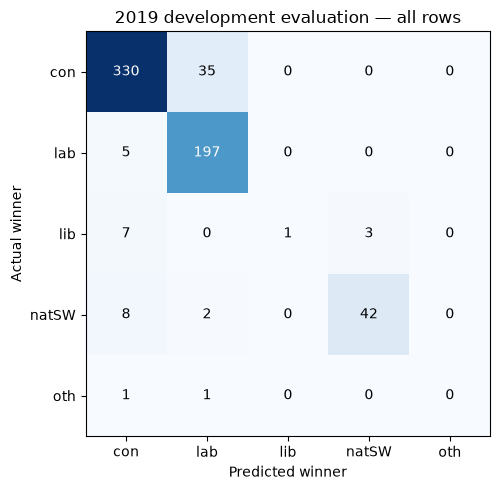

In [8]:
labels = model.classes_
party_report = pd.DataFrame(classification_report(evaluation_data.winner, evaluation_predictions,
                                                labels=labels, output_dict=True, zero_division=0)).T
display(party_report)
seat_totals = pd.DataFrame({"actual_seats": evaluation_data.winner.value_counts().reindex(labels, fill_value=0),
                            "predicted_seats": pd.Series(evaluation_predictions).value_counts().reindex(labels, fill_value=0)})
seat_totals["error"] = seat_totals.predicted_seats - seat_totals.actual_seats
display(seat_totals)
cm = confusion_matrix(evaluation_data.winner, evaluation_predictions, labels=labels)
fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(cm, cmap="Blues")
ax.set(xticks=range(len(labels)), yticks=range(len(labels)), xticklabels=labels, yticklabels=labels,
       xlabel="Predicted winner", ylabel="Actual winner", title="2019 development evaluation — all rows")
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, str(cm[i,j]), ha="center", va="center", color="white" if cm[i,j] > cm.max()/2 else "black")
fig.tight_layout()
plt.show()


## 7. Save the audit trail and verify against the preceding study

This writes only to this notebook's result directory. When the previous study's data hash matches, its corresponding 32/16, patience-20 results are checked as a reproducibility test. That reference does not select the model: it is read only after fitting and evaluation.

In [9]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
data_hash = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
configuration = {"data_sha256": data_hash, "training_elections": model.training_elections,
                 "validation_year": model.validation_year, "evaluation_year": EVALUATION_YEAR,
                 "selection_metric": "ensemble_validation_log_loss", "hyperparameters": model.hyperparameters,
                 "features": FEATURE_COLUMNS, "classes": model.classes_.tolist(),
                 "versions": {"python": platform.python_version(), "torch": torch.__version__,
                              "sklearn": sklearn.__version__, "numpy": np.__version__, "pandas": pd.__version__}}
(OUTPUT_DIR / "configuration.json").write_text(json.dumps(configuration, indent=2))
model.learning_rate_summary.to_csv(OUTPUT_DIR / "learning_rate_validation.csv", index=False)
model.training_records.to_csv(OUTPUT_DIR / "training_records.csv", index=False)
metrics_2019.to_csv(OUTPUT_DIR / "evaluation_2019.csv", index=False)
party_report.to_csv(OUTPUT_DIR / "party_report_2019.csv")
seat_totals.to_csv(OUTPUT_DIR / "seat_totals_2019.csv")
prediction_table = evaluation_data[["constituency_name", "election", "winner", "previous_winner"]].copy()
prediction_table.insert(0, "source_row", evaluation_data.index)
prediction_table["prediction"] = evaluation_predictions
prediction_table["complete_predictors"] = complete
for i, label in enumerate(model.classes_):
    prediction_table["p_" + label] = evaluation_probabilities[:, i]
prediction_table.to_csv(OUTPUT_DIR / "predictions_2019.csv", index=False)
fig.savefig(OUTPUT_DIR / "confusion_matrix_2019.png", dpi=150)
assert len(model.training_records) == 40
assert not model.training_records.duplicated(["learning_rate", "seed"]).any()
assert (model.training_records.best_epoch <= model.training_records.stopping_epoch).all()
assert model.selected_learning_rate == model.learning_rate_summary.loc[model.learning_rate_summary.log_loss.idxmin(), "learning_rate"]
reference_dir = ROOT / "Analysis and model development/nn_architecture_study"
if (reference_dir / "configuration.json").exists() and (reference_dir / "confirmation_results.csv").exists():
    reference_config = json.loads((reference_dir / "configuration.json").read_text())
    if reference_config["data_sha256"] == data_hash:
        reference = pd.read_csv(reference_dir / "confirmation_results.csv")
        reference = reference.loc[(reference.architecture == "32_16") & (reference.patience == 20)
                                  & (reference.train_through == 2015) & reference.learning_rate.isin(LEARNING_RATES)]
        merged = model.learning_rate_summary.merge(reference, on="learning_rate")
        assert len(merged) == len(LEARNING_RATES)
        np.testing.assert_allclose(merged.log_loss, merged.validation_log_loss, rtol=1e-6, atol=1e-7)
        selected_reference = reference.loc[reference.learning_rate == model.selected_learning_rate].iloc[0]
        actual = metrics_2019.iloc[0]
        for metric in ["accuracy", "changed_seat_accuracy", "log_loss", "brier_score"]:
            np.testing.assert_allclose(actual[metric], selected_reference["evaluation_" + metric], rtol=1e-6, atol=1e-7)
        print("Verified: all four validation results and selected 2019 metrics reproduce notebook 07.")
    else:
        print("Reference data hash differs; no claim of reproducing old scores.")
print("40 fits checked; pipeline files unchanged. Results:", OUTPUT_DIR)


Verified: all four validation results and selected 2019 metrics reproduce notebook 07.
40 fits checked; pipeline files unchanged. Results: /workspaces/Election-Prediction-12.08/Analysis and model development/nn_proposed_pipeline_2019_results


## How this would fit into automated model selection later

1. Supply the neural candidate with pre-2019 data. Its `train` method holds out all of 2017 and updates weights through 2015, as demonstrated above.
2. Have every candidate predict the **same 2019 evaluation rows**. The existing selector's complete-row filter and composite score are shown above for compatibility. This notebook has not trained the other candidates, so it cannot establish which family wins.
3. If the neural candidate wins the declared comparison, a later `retrain` call using all historical data through 2019 would hold out **all of 2019** for checkpoint/rate selection and update weights through **2017**. That is a new fitted ensemble; it is not the model whose 2019 scores were measured here.
4. Evaluate that later fitted model only on a later election. Do not report its in-sample/validation 2019 score as the result above.

The wrapper is an explanatory prototype with compatible method names, not an installed replacement for `Models/NN01_model.py`. Actual integration would preserve the project's model contract and deliberately decide the common evaluation-row and selection-metric rules. The existing pipeline, SQL, prepared CSVs and model files remain unchanged.

The 2019 result is one part of the historical evidence. Notebook 07 found weaker transfer to 2015 and 2005, so this demonstration does not override those limitations or justify forcing a neural model to win.